In [7]:
import os

os.chdir('/home/slagter/Astronomy_master/STRW-MSC/SF_in_NGC')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from astropy.io import ascii

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
gaia_cat_path =  '/net/vdesk/data2/slagter/JWST_NIRCAM_#1227_level_2/ngc346_gaia_dr3_10arcmin.txt'
gaia_cat_path_clean =   '/net/vdesk/data2/slagter/JWST_NIRCAM_#1227_level_2/ngc346_gaia_dr3_10arcmin_clean.txt'

names = ['source_id','ra','dec','parallax','pmra','pmdec',
         'phot_g_mean_mag','phot_g_mean_flux_over_error',
         'phot_bp_mean_mag','phot_bp_mean_flux_over_error',
         'phot_rp_mean_mag','phot_rp_mean_flux_over_error',
         'phot_g_mean_mag_error','phot_bp_mean_mag_error','phot_rp_mean_mag_error']

# df = pd.read_csv(gaia_cat_path, sep=r'\s+', comment='#', header=None,
#                  names=names, na_values=['""','"'], quoting=csv.QUOTE_NONE)
# df = df.replace("|", " ")
# df.to_csv(gaia_cat_path_clean, sep=' ', index=False, na_rep='NaN')

df = pd.read_csv(
    gaia_cat_path,
    sep='|',
    skiprows=[1],                 # drop the '-----|-----' line (header is row 0)
    skipinitialspace=True,
    dtype={'source_id': 'int64'}, # keep the full 19-digit ID exact
    na_values=['', ' ', 'null', 'NaN'],
)

df.columns = df.columns.str.strip()

for c in df.columns.drop('source_id'):
    df[c] = pd.to_numeric(df[c], errors='coerce')


prefac      = 2.5 / np.log(10)  # 2.5/ln(10)
sigmaG_0    = 0.0027553202
sigmaGBP_0  = 0.0027901700
sigmaGRP_0  = 0.0037793818

# https://astronomy.stackexchange.com/questions/38371/how-can-i-calculate-the-uncertainties-in-magnitude-like-the-cds-does
# compute the magnitude error from the flux error
df["phot_g_mean_mag_error"]  = np.sqrt((prefac / df["phot_g_mean_flux_over_error"])**2  + sigmaG_0**2)
df["phot_bp_mean_mag_error"] = np.sqrt((prefac / df["phot_bp_mean_flux_over_error"])**2 + sigmaGBP_0**2)
df["phot_rp_mean_mag_error"] = np.sqrt((prefac / df["phot_rp_mean_flux_over_error"])**2 + sigmaGRP_0**2)


df.to_csv(gaia_cat_path_clean, sep=' ', index=False, na_rep='NaN')


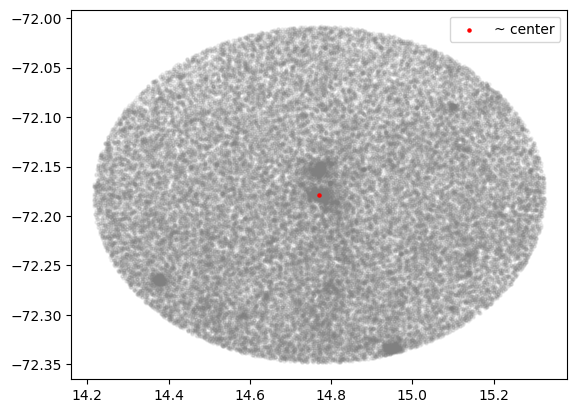

In [11]:
table = ascii.read(gaia_cat_path_clean)

plt.scatter(table['ra'], table['dec'], rasterized=True, alpha=0.1 ,s=5, c='grey')
plt.scatter(14.770821063331482, -72.17833229841659, c='red', label='~ center', s=5)
plt.legend()